In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 경로 리스트
file_paths = [
    "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/201807_train_회원정보.parquet",
    "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/201808_train_회원정보.parquet",
    "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/201809_train_회원정보.parquet",
    "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/201810_train_회원정보.parquet",
    "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/201811_train_회원정보.parquet",
    "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/201812_train_회원정보.parquet"
]

# 2. 데이터 불러오기 + 기준년월 추가
df_list = []
for path in file_paths:
    df = pd.read_parquet(path)
    기준년월 = os.path.basename(path).split('_')[0]
    df['기준년월'] = 기준년월
    df_list.append(df)

# 3. 세로 병합
merged_df = pd.concat(df_list, ignore_index=True)

# 4. segment 컬럼 자동 탐색
segment_col_candidates = [col for col in merged_df.columns if 'segment' in col.lower()]
print("사용 가능한 segment 컬럼 후보:", segment_col_candidates)

# 5. segment 컬럼 선택
segment_col = segment_col_candidates[-1]

# 6. 범주형 segment → 숫자형으로 변환
if merged_df[segment_col].dtype == 'object':
    merged_df[segment_col] = merged_df[segment_col].astype('category').cat.codes

# 7. 숫자형 컬럼만 추출
numeric_cols = merged_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 8. 결측치 제거 및 std=0 컬럼 제거
clean_df = merged_df[numeric_cols + [segment_col]].dropna()
clean_df = clean_df.loc[:, clean_df.std() != 0]

# 9. 상관관계 계산
corr_dict = {
    col: clean_df[segment_col].corr(clean_df[col])
    for col in clean_df.columns if col != segment_col
}

# 10. 정리 및 출력
corr_df = pd.DataFrame.from_dict(corr_dict, orient='index', columns=['상관계수'])
corr_df = corr_df.sort_values(by='상관계수', key=abs, ascending=False)

# 인덱스를 컬럼으로 변환해 가독성 향상
corr_df.reset_index(inplace=True)
corr_df.rename(columns={'index': '컬럼명'}, inplace=True)

#  보기 좋게 스타일링
styled = corr_df.style.background_gradient(cmap='coolwarm', subset=['상관계수']) \
                    .set_properties(**{'text-align': 'center'}) \
                    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

#  주피터에서 예쁘게 출력
display(styled)


사용 가능한 segment 컬럼 후보: ['Segment']


,컬럼명,상관계수
0,이용금액_R3M_신용체크,-0.623582
1,이용금액_R3M_신용,-0.589792
2,_1순위카드이용금액,-0.574799
3,_2순위카드이용금액,-0.386804
4,이용카드수_신용체크,-0.381942
5,이용카드수_신용,-0.359620
6,_2순위카드이용건수,-0.358716
7,_1순위카드이용건수,-0.356594
8,이용가능카드수_신용체크,-0.345848
9,이용가능카드수_신용,-0.345561


In [2]:
# 상관계수 컬럼이 float인지 다시 한번 확인 후 진행
corr_df['상관계수'] = pd.to_numeric(corr_df['상관계수'], errors='coerce')

# 0.3 이하인 컬럼 추출 (절대값 기준)
corr_under_03 = corr_df[abs(corr_df['상관계수']) <= 0.3]

# 출력
print("✅ 상관계수 0.3 이하 변수 수:", len(corr_under_03))
display(corr_under_03)


✅ 상관계수 0.3 이하 변수 수: 43


,컬럼명,상관계수
14,입회일자_신용,0.259782
15,입회경과개월수_신용,-0.259779
16,이용금액_R3M_신용_가족,-0.233500
17,이용카드수_신용_가족,-0.211953
18,유효카드수_신용_가족,-0.211731
19,이용가능카드수_신용_가족,-0.211592
20,이용금액_R3M_체크,-0.203347
21,이용여부_3M_해외겸용_본인,-0.161672
22,유효카드수_체크,-0.153470
23,이용카드수_체크,-0.153411


In [3]:
# [1] 0.3 이하 상관관계 컬럼만 필터링
corr_under_02 = corr_df[abs(corr_df['상관계수']) <= 0.3]

# [2] 변수 리스트 추출
low_corr_vars = corr_under_02['컬럼명'].unique().tolist()

# [3] clean_df에서 추출
eda_df = clean_df[low_corr_vars + ['Segment']]

# [4] 저장
eda_df.to_csv("회원정보_low_corr_segment_data.csv", index=False, encoding='utf-8-sig')
print("✅ 저장 완료: low_corr_segment_data.csv")


✅ 저장 완료: low_corr_segment_data.csv


In [4]:
import pandas as pd

# CSV 파일 경로
file_path = "C:/Users/HR/Desktop/workspace/파이널프로젝트/회원정보_low_corr_segment_data.csv"

# 데이터 불러오기
df = pd.read_csv(file_path)

# 미리보기
df.head()


,입회일자_신용,입회경과개월수_신용,이용금액_R3M_신용_가족,이용카드수_신용_가족,유효카드수_신용_가족,이용가능카드수_신용_가족,이용금액_R3M_체크,이용여부_3M_해외겸용_본인,유효카드수_체크,이용카드수_체크,...,회원여부_연체,탈회횟수_발급6개월이내,기본연회비_B0M,청구금액_기본연회비_B0M,회원여부_이용가능_CA,최종탈회후경과월,유효카드수_체크_가족,이용가능카드수_체크_가족,회원여부_이용가능,Segment
0,20130101,67,0,0,0,0,0,0,1,0,...,0,0,0,0,1,61,0,0,1,3
1,20170801,12,0,0,0,0,0,0,0,0,...,0,0,0,0,1,98,0,0,1,4
2,20080401,124,0,0,0,0,0,0,1,0,...,0,0,0,0,1,60,0,0,1,2
3,20160501,27,0,0,0,0,0,1,1,0,...,0,0,0,0,1,100,0,0,1,3
4,20180601,2,0,0,0,0,0,0,0,0,...,0,0,0,0,1,44,0,0,1,4


## 데이터 기본 정보 확인

In [5]:
# 행/열 크기 확인
print("✅ 데이터 크기 (행, 열):", df.shape)

# 컬럼 타입 및 결측치 여부 확인
print("\n✅ 컬럼별 타입 및 결측치:")
print(df.info())

# 수치형 요약 통계
print("\n✅ 수치형 변수 요약 통계:")
print(df.describe())


✅ 데이터 크기 (행, 열): (1864681, 44)

✅ 컬럼별 타입 및 결측치:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1864681 entries, 0 to 1864680
Data columns (total 44 columns):
 #   Column              Dtype  
---  ------              -----  
 0   입회일자_신용             int64  
 1   입회경과개월수_신용          int64  
 2   이용금액_R3M_신용_가족      int64  
 3   이용카드수_신용_가족         int64  
 4   유효카드수_신용_가족         int64  
 5   이용가능카드수_신용_가족       int64  
 6   이용금액_R3M_체크         int64  
 7   이용여부_3M_해외겸용_본인     int64  
 8   유효카드수_체크            int64  
 9   이용카드수_체크            int64  
 10  이용가능카드수_체크          int64  
 11  이용여부_3M_해외겸용_신용_본인  int64  
 12  보유여부_해외겸용_신용_본인     int64  
 13  이용가능여부_해외겸용_신용_본인   int64  
 14  이용가능여부_해외겸용_본인      int64  
 15  보유여부_해외겸용_본인        int64  
 16  수신거부여부_TM           int64  
 17  수신거부여부_메일           int64  
 18  수신거부여부_DM           int64  
 19  수신거부여부_SMS          int64  
 20  남녀구분코드              int64  
 21  탈회횟수_누적             int64  
 22  최종유효년월_신용_이용        float64
 23  최종유효년월_신용

## 결측치 확인

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 결측치 개수 출력
print("✅ 컬럼별 결측치 개수:")
print(df.isnull().sum())



✅ 컬럼별 결측치 개수:
입회일자_신용               0
입회경과개월수_신용            0
이용금액_R3M_신용_가족        0
이용카드수_신용_가족           0
유효카드수_신용_가족           0
이용가능카드수_신용_가족         0
이용금액_R3M_체크           0
이용여부_3M_해외겸용_본인       0
유효카드수_체크              0
이용카드수_체크              0
이용가능카드수_체크            0
이용여부_3M_해외겸용_신용_본인    0
보유여부_해외겸용_신용_본인       0
이용가능여부_해외겸용_신용_본인     0
이용가능여부_해외겸용_본인        0
보유여부_해외겸용_본인          0
수신거부여부_TM             0
수신거부여부_메일             0
수신거부여부_DM             0
수신거부여부_SMS            0
남녀구분코드                0
탈회횟수_누적               0
최종유효년월_신용_이용          0
최종유효년월_신용_이용가능        0
회원여부_이용가능_카드론         0
카드신청건수                0
마케팅동의여부               0
최종카드발급경과월             0
최종카드발급일자              0
탈회횟수_발급1년이내           0
동의여부_한도증액안내           0
이용거절여부_카드론            0
제휴연회비_B0M             0
청구금액_제휴연회비_B0M        0
회원여부_연체               0
탈회횟수_발급6개월이내          0
기본연회비_B0M             0
청구금액_기본연회비_B0M        0
회원여부_이용가능_CA          0
최종탈회후경과월              0
유효카드수_체크_가족           0
이용

## 수치형 변수 분포 시각화

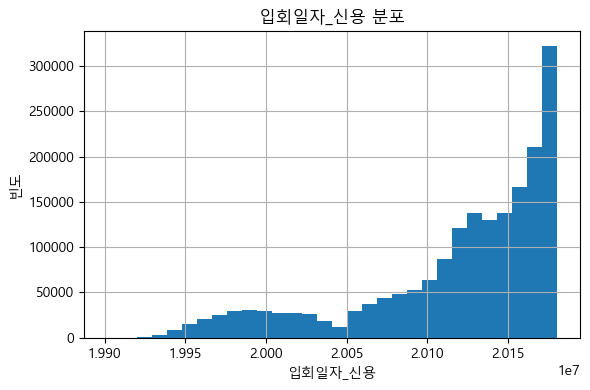

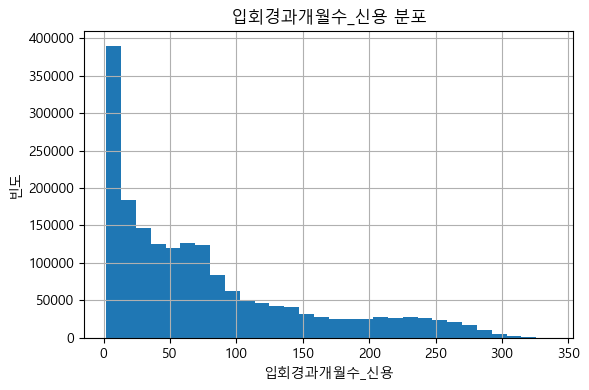

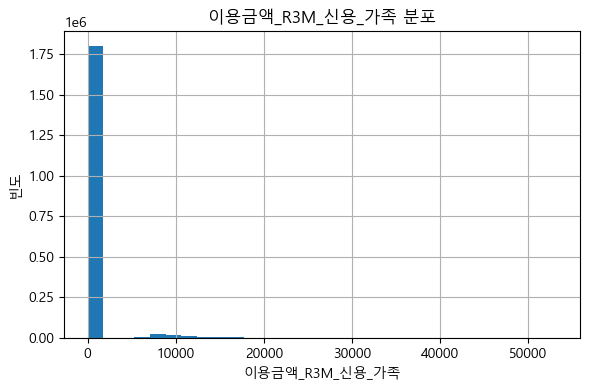

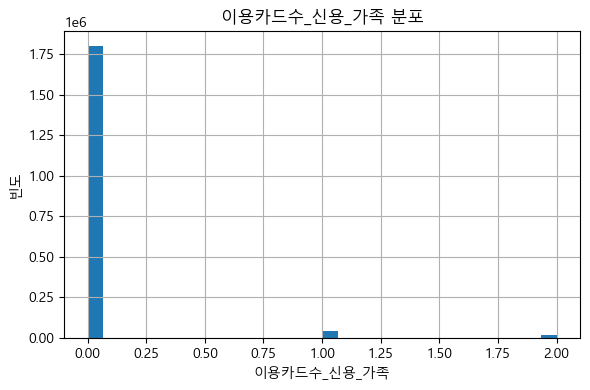

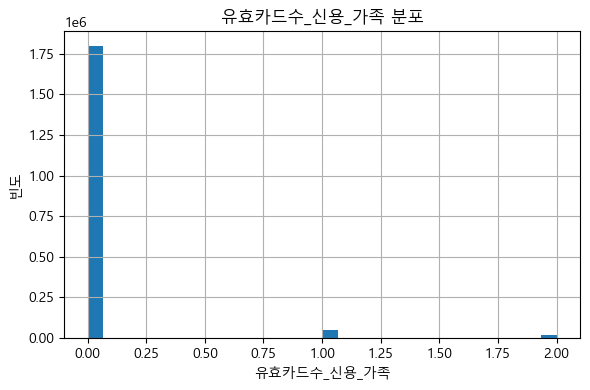

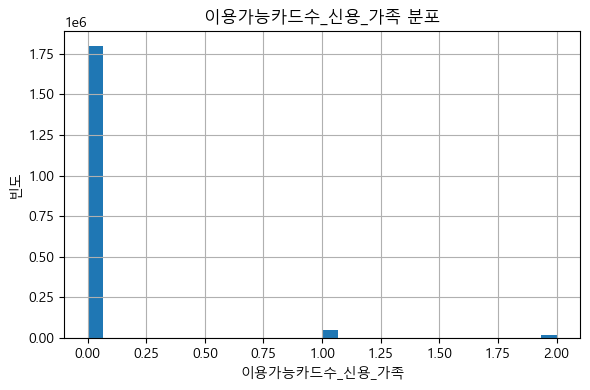

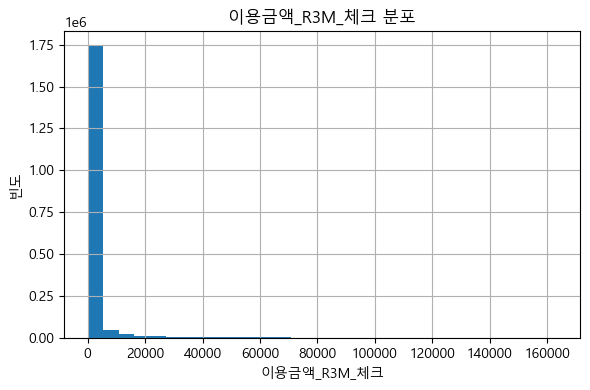

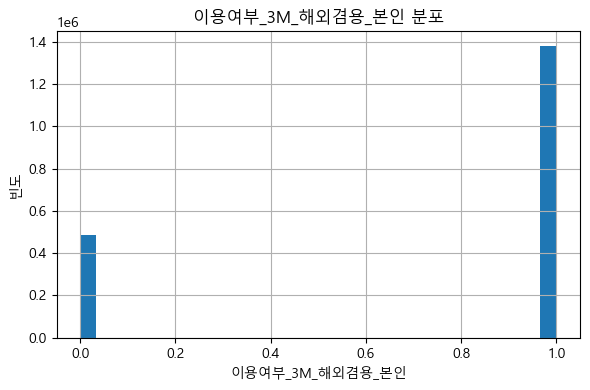

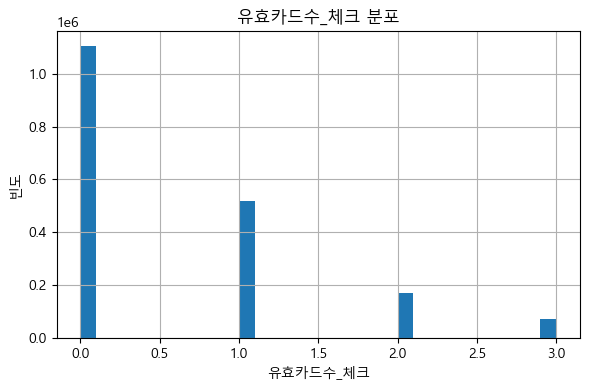

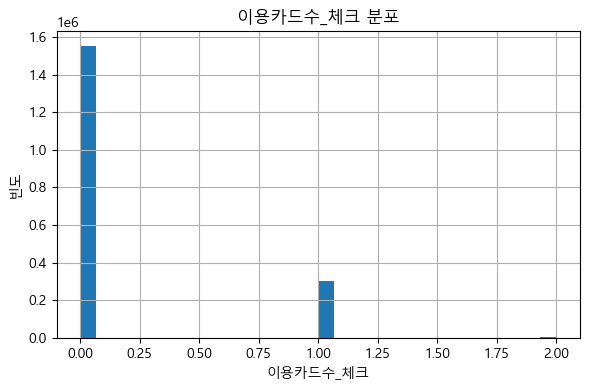

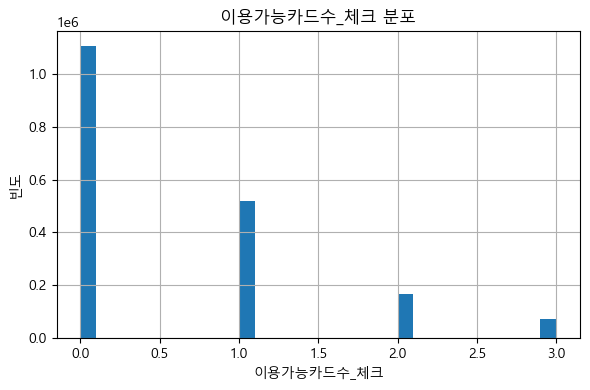

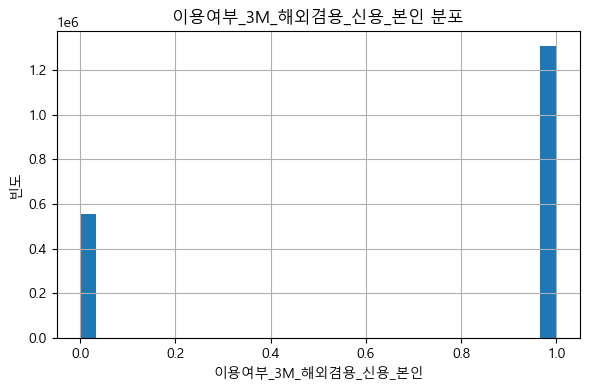

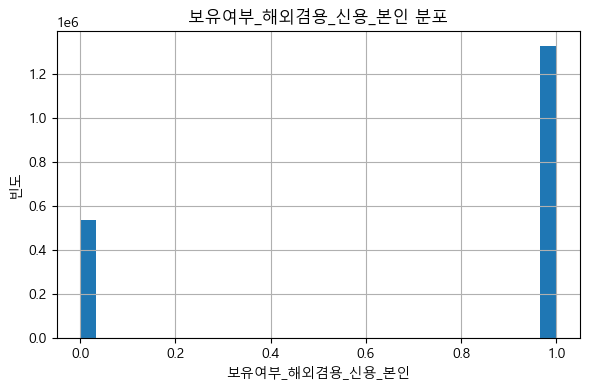

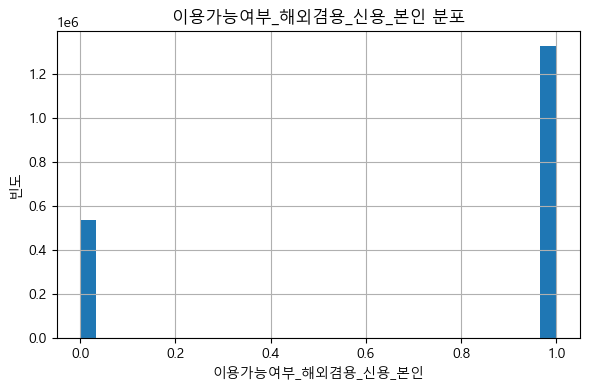

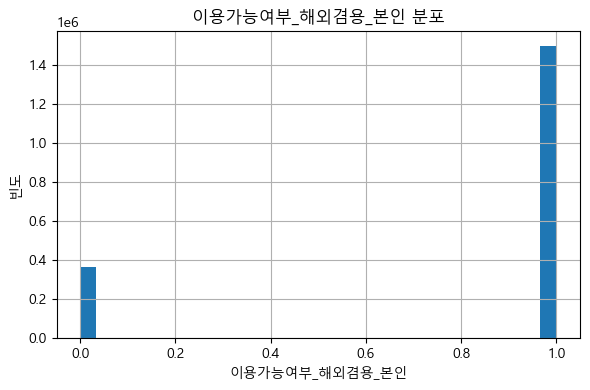

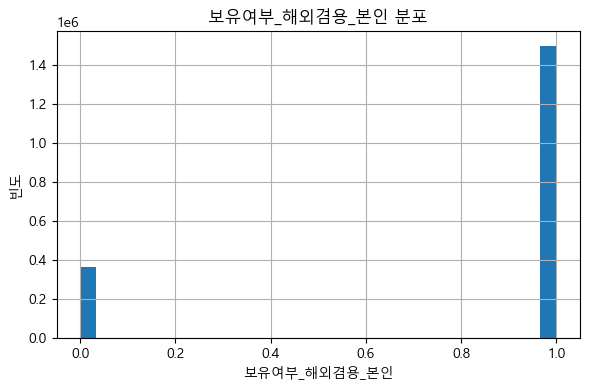

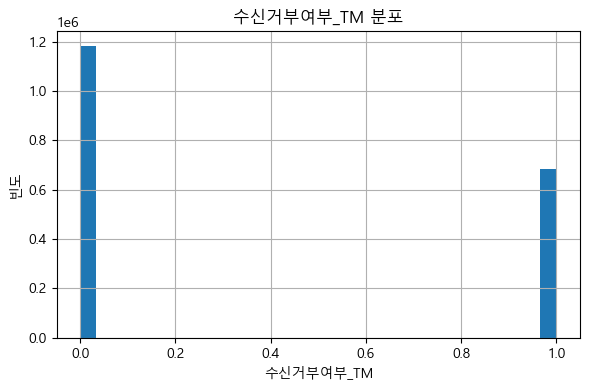

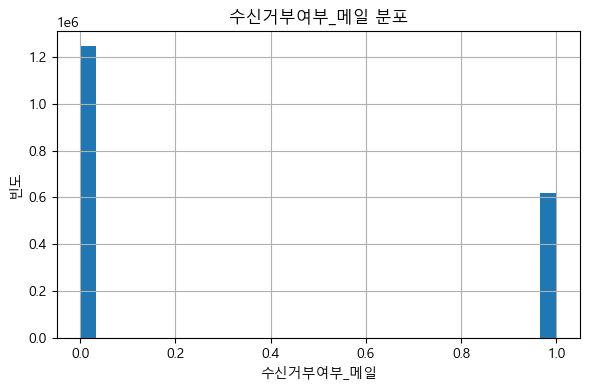

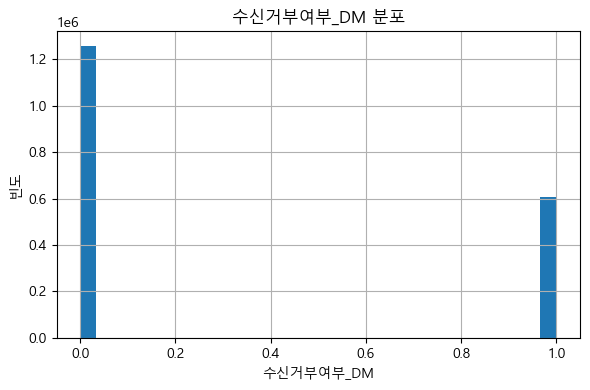

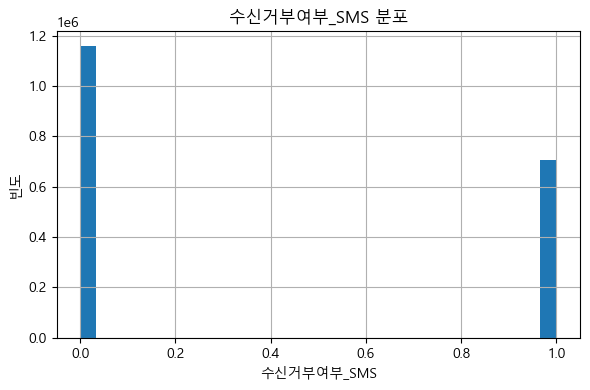

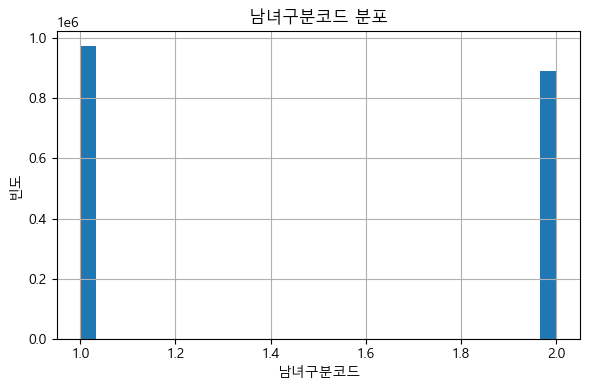

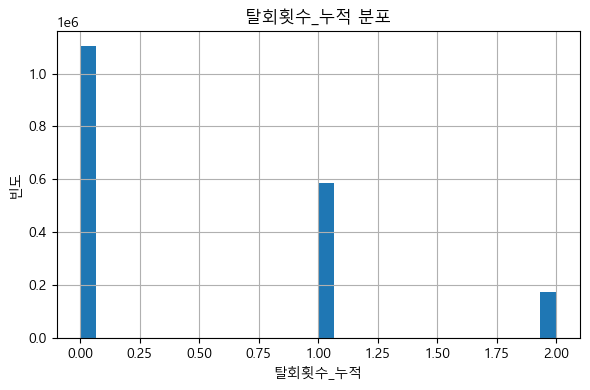

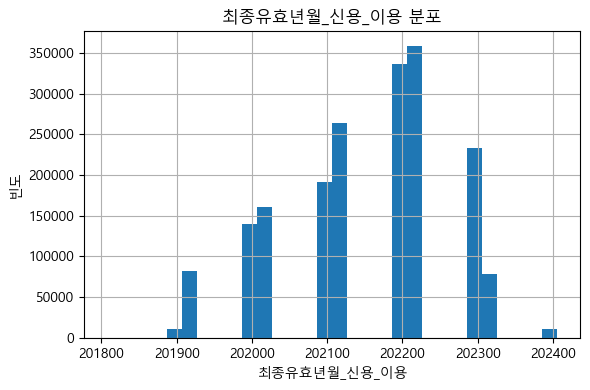

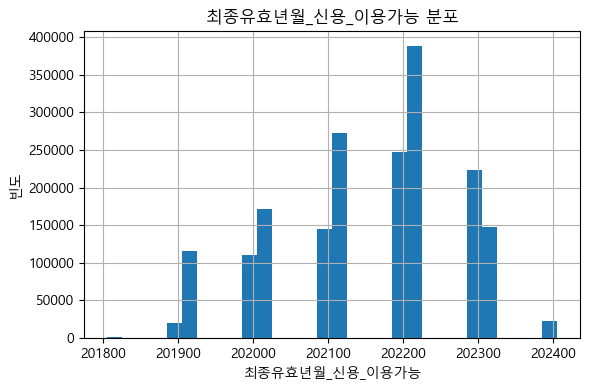

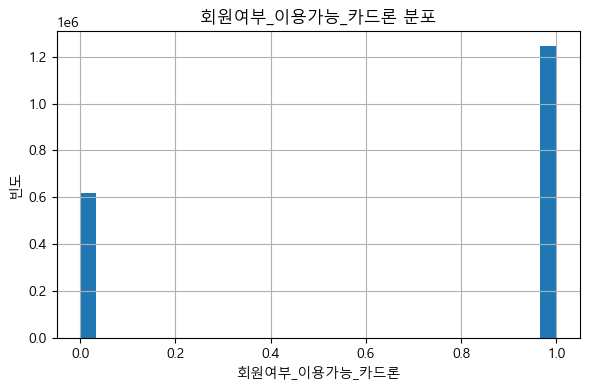

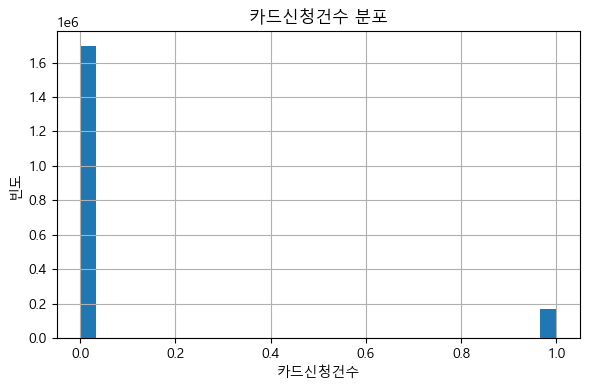

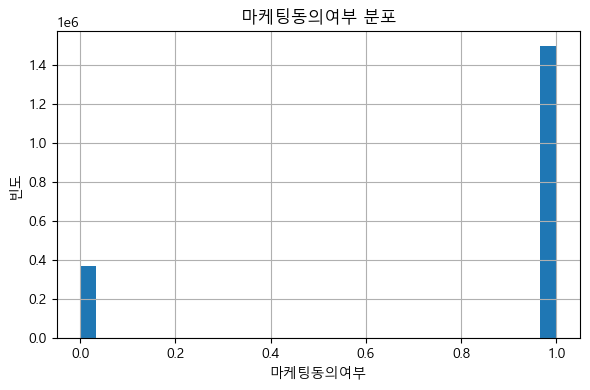

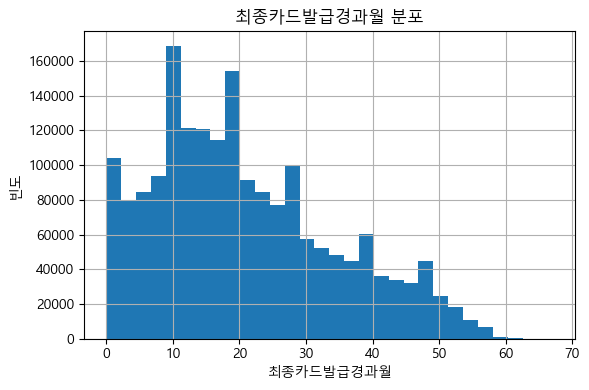

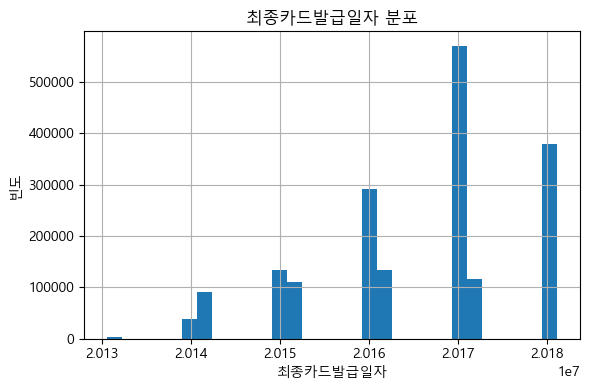

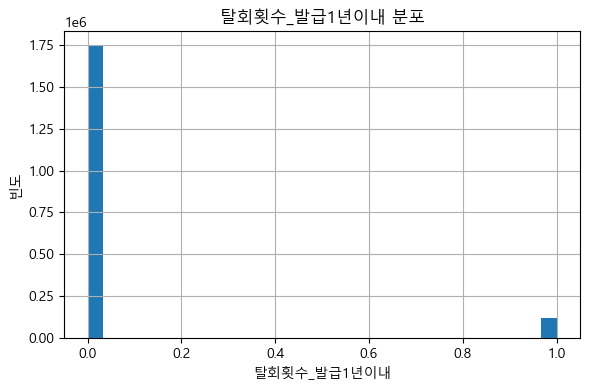

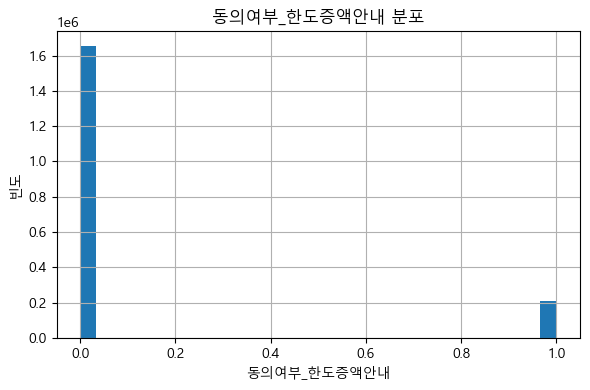

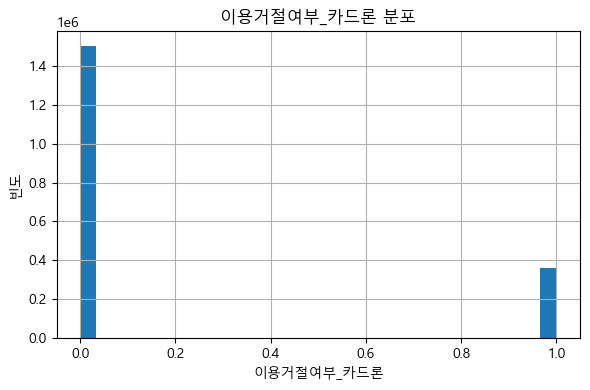

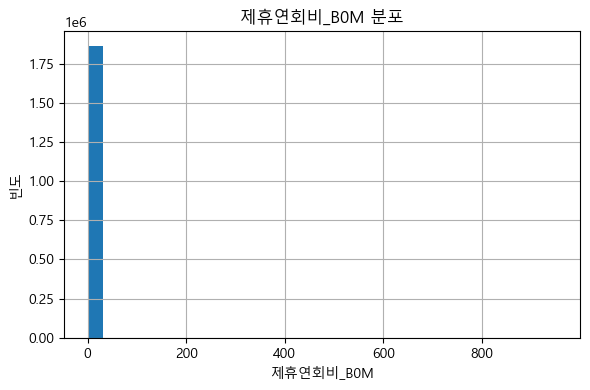

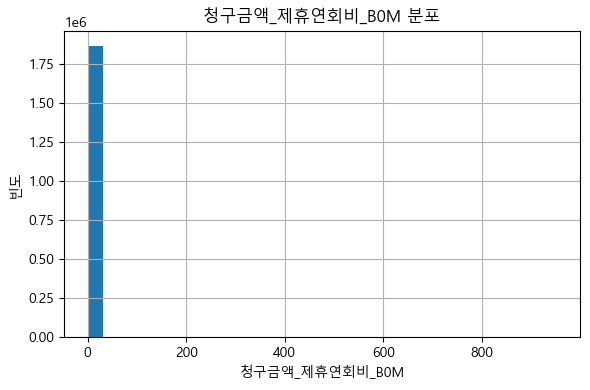

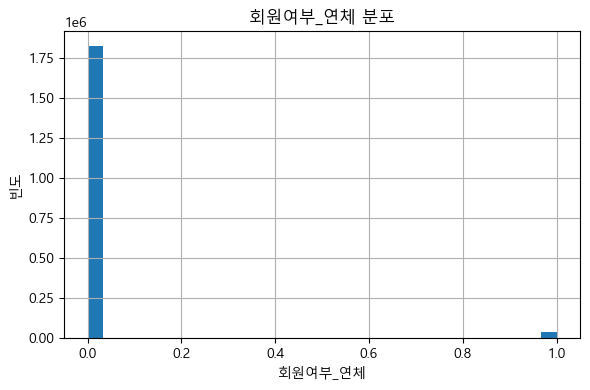

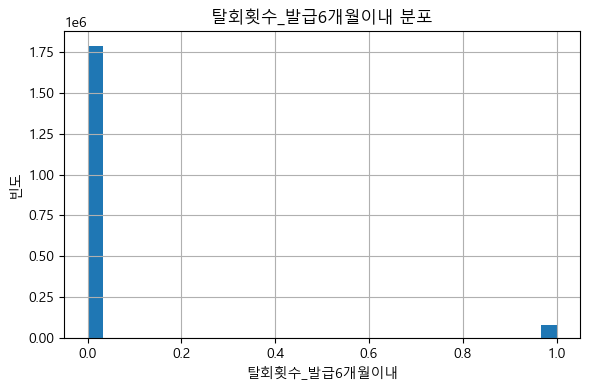

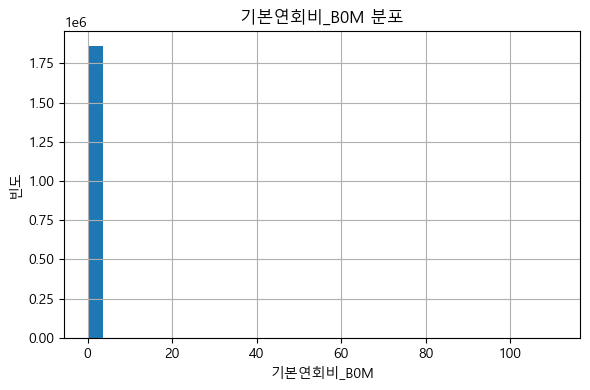

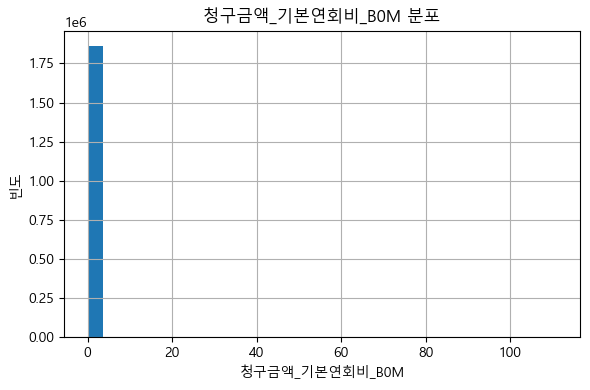

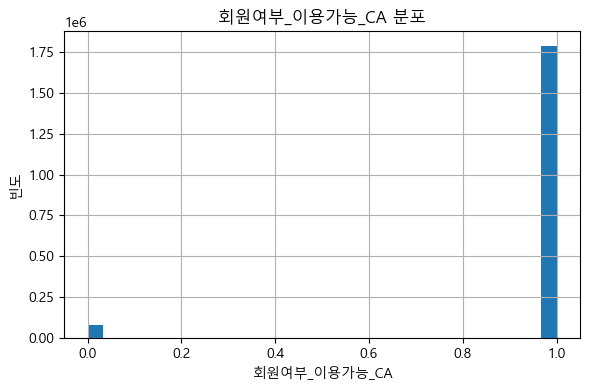

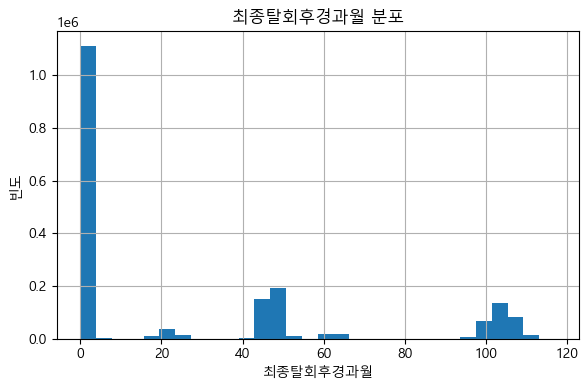

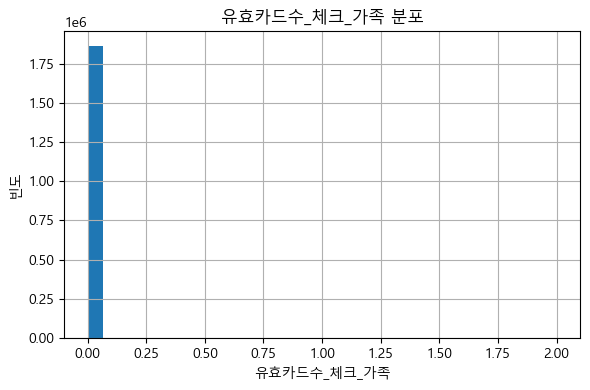

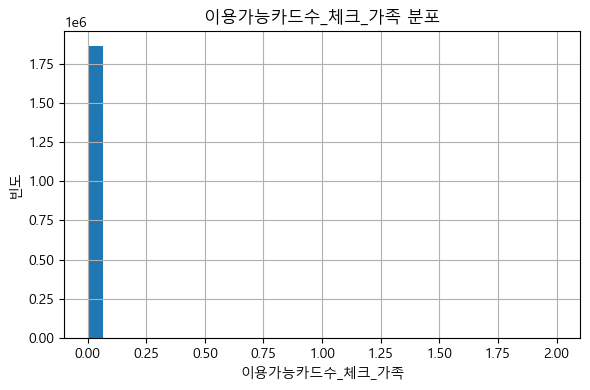

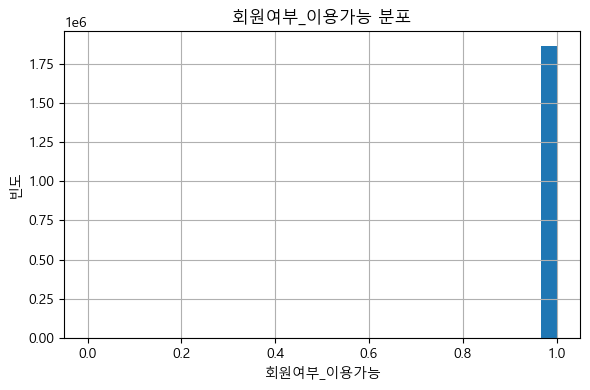

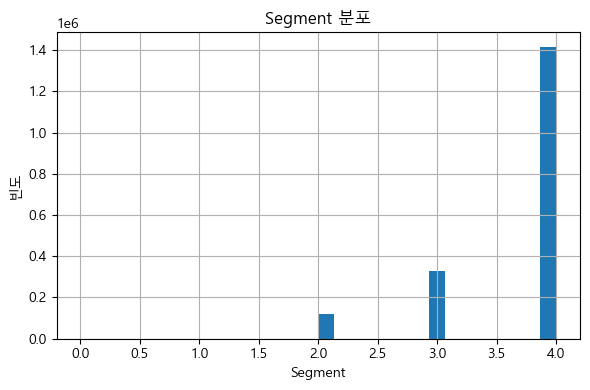

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False


# 수치형 컬럼만 추출
numeric_cols = df.select_dtypes(include='number').columns

# 히스토그램 반복 생성
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"{col} 분포")
    plt.xlabel(col)
    plt.ylabel("빈도")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Segment별 평균값 요약

In [8]:
# Segment 컬럼 기준 그룹별 평균 계산
segment_summary = df.groupby('Segment').mean(numeric_only=True)

# 보기 좋게 출력
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

from IPython.display import display

# 시각적으로 강조된 테이블 출력
display(segment_summary.style
        .background_gradient(cmap='YlGnBu')
        .format(precision=2)
        .set_caption("Segment별 평균값 요약"))


,입회일자_신용,입회경과개월수_신용,이용금액_R3M_신용_가족,이용카드수_신용_가족,유효카드수_신용_가족,이용가능카드수_신용_가족,이용금액_R3M_체크,이용여부_3M_해외겸용_본인,유효카드수_체크,이용카드수_체크,이용가능카드수_체크,이용여부_3M_해외겸용_신용_본인,보유여부_해외겸용_신용_본인,이용가능여부_해외겸용_신용_본인,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,수신거부여부_SMS,남녀구분코드,탈회횟수_누적,최종유효년월_신용_이용,최종유효년월_신용_이용가능,회원여부_이용가능_카드론,카드신청건수,마케팅동의여부,최종카드발급경과월,최종카드발급일자,탈회횟수_발급1년이내,동의여부_한도증액안내,이용거절여부_카드론,제휴연회비_B0M,청구금액_제휴연회비_B0M,회원여부_연체,탈회횟수_발급6개월이내,기본연회비_B0M,청구금액_기본연회비_B0M,회원여부_이용가능_CA,최종탈회후경과월,유효카드수_체크_가족,이용가능카드수_체크_가족,회원여부_이용가능
Segment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,20015893.95,201.27,4174.67,0.39,0.39,0.39,1212.77,0.99,0.43,0.09,0.43,0.98,0.99,0.99,0.99,0.99,0.52,0.47,0.44,0.55,1.29,0.34,202134.29,202143.13,0.62,0.05,0.76,20.90,20165442.73,0.01,0.13,0.16,0.00,0.00,0.01,0.00,0.00,0.00,0.99,22.12,0.00,0.00,1.00
1,20075996.83,130.04,3157.32,0.25,0.27,0.26,2758.88,0.96,1.00,0.35,0.94,0.96,0.96,0.96,0.96,0.96,0.40,0.30,0.29,0.42,1.46,0.45,202133.43,202134.96,0.40,0.05,0.88,20.50,20166082.71,0.04,0.34,0.07,0.00,0.00,0.04,0.01,0.00,0.00,0.96,36.65,0.00,0.00,1.00
2,20072659.79,133.39,1823.87,0.20,0.20,0.20,5852.47,0.91,0.87,0.30,0.86,0.88,0.88,0.88,0.94,0.94,0.49,0.45,0.44,0.49,1.39,0.40,202138.75,202140.42,0.62,0.07,0.76,21.58,20165130.34,0.04,0.15,0.14,1.54,1.54,0.02,0.03,0.03,0.03,0.96,27.00,0.00,0.00,1.00
3,20101384.77,98.95,785.81,0.10,0.10,0.10,4102.94,0.85,0.78,0.27,0.77,0.80,0.81,0.81,0.89,0.89,0.45,0.42,0.41,0.45,1.43,0.42,202139.71,202141.14,0.62,0.06,0.78,22.08,20164694.81,0.05,0.12,0.19,0.94,0.94,0.03,0.03,0.06,0.06,0.96,27.41,0.00,0.00,1.00
4,20127971.39,67.13,129.89,0.02,0.02,0.02,885.07,0.70,0.50,0.14,0.50,0.66,0.68,0.68,0.77,0.77,0.33,0.30,0.30,0.35,1.50,0.53,202157.13,202158.25,0.68,0.10,0.81,20.55,20165974.79,0.07,0.11,0.20,0.23,0.23,0.02,0.04,0.18,0.18,0.96,27.79,0.00,0.00,1.00


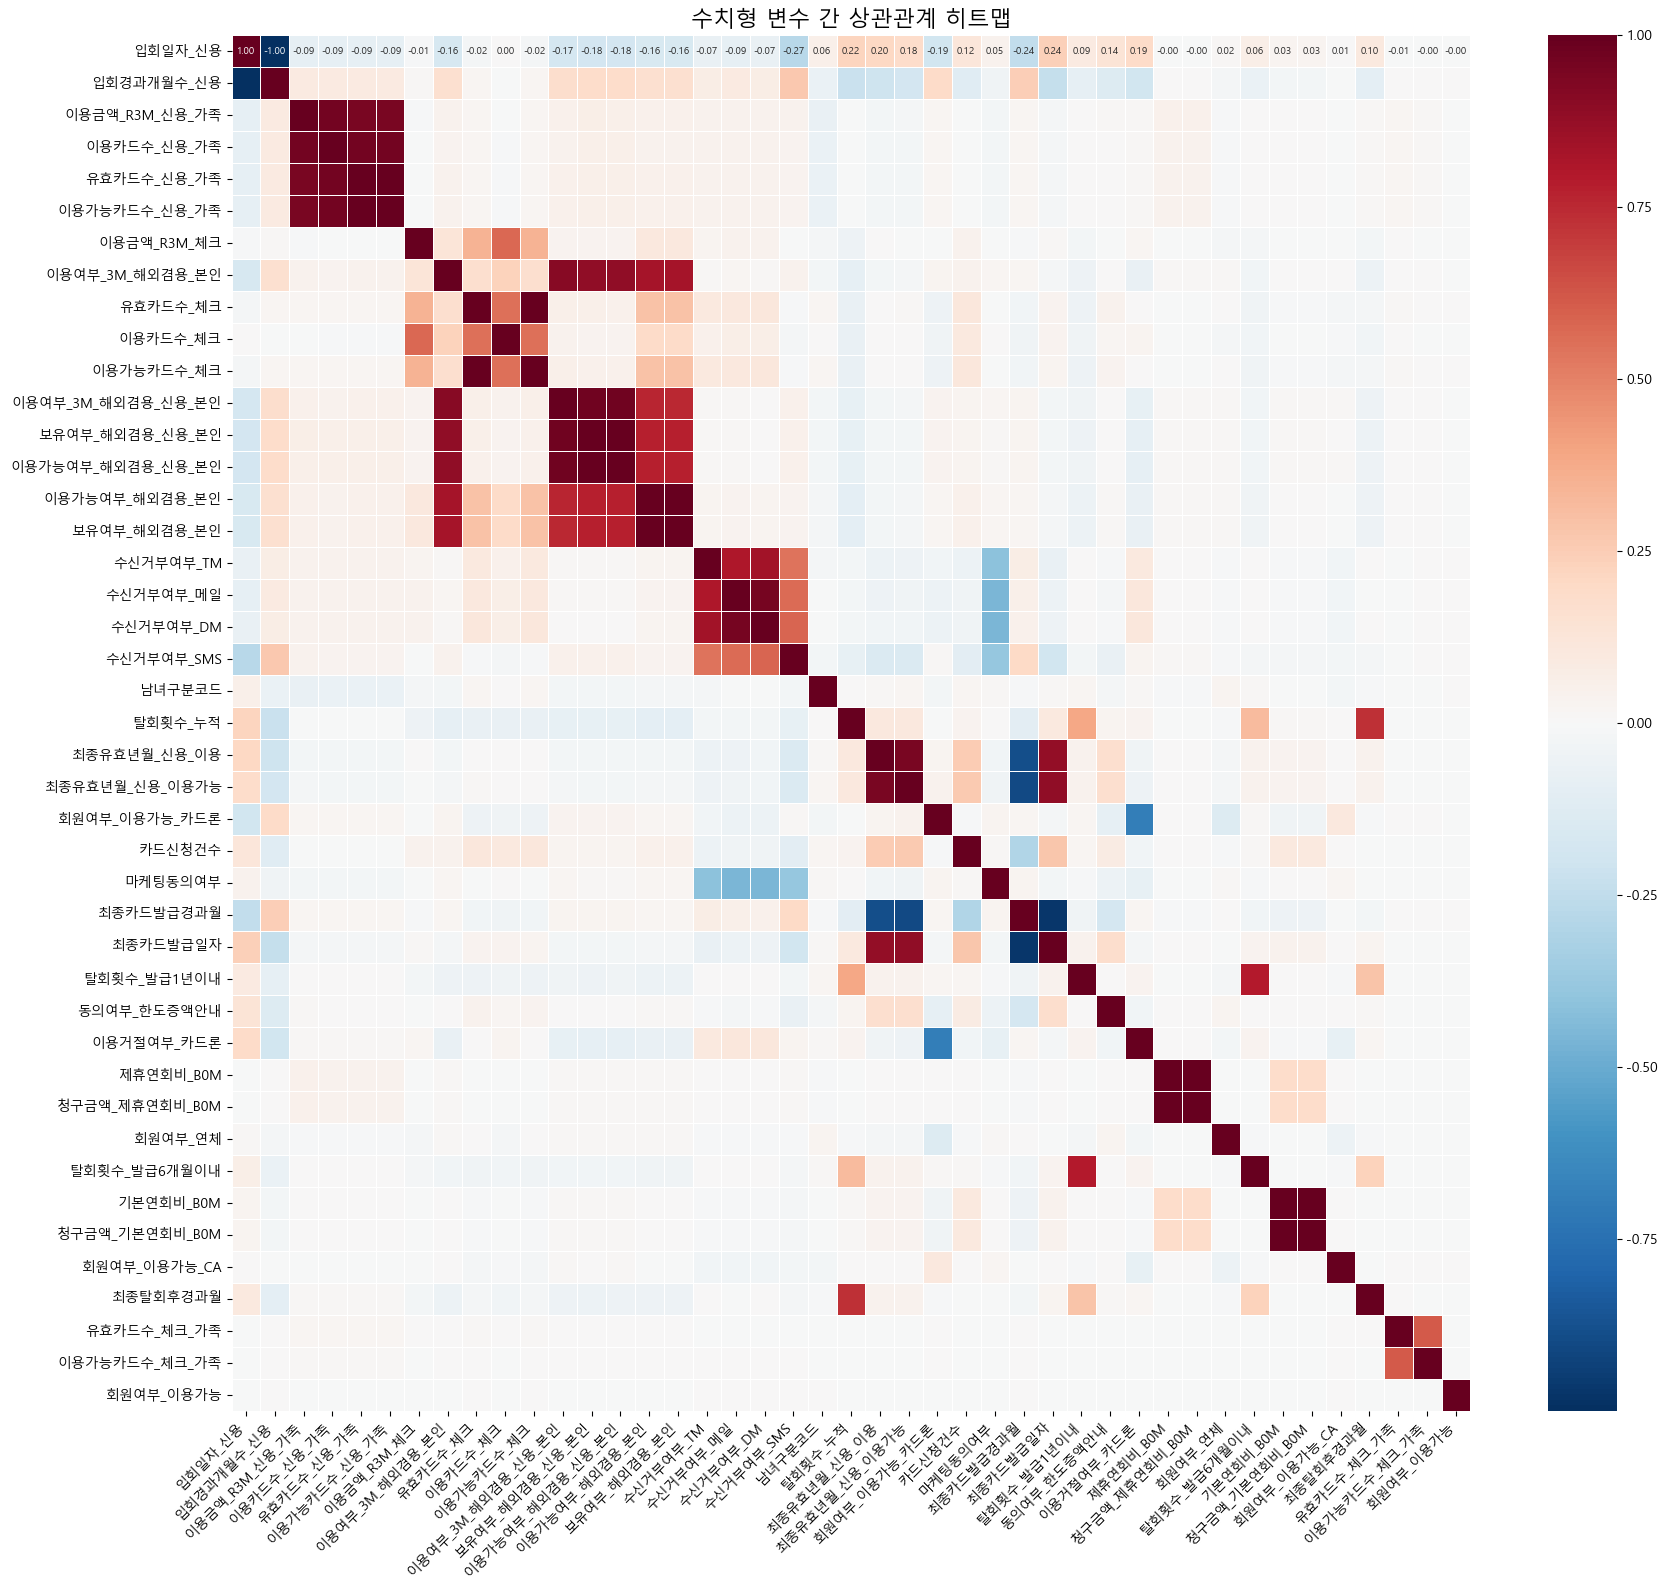

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 상관계수 계산
corr_matrix = df.drop(columns=['Segment']).corr(numeric_only=True)

# 히트맵 그리기
plt.figure(figsize=(18, 16))  # ✅ 크기 넉넉하게
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap='RdBu_r',
    linewidths=0.5,
    center=0,
    cbar=True,
    annot_kws={"size": 7}  # ✅ 숫자 크기 줄임
)
plt.title("수치형 변수 간 상관관계 히트맵", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [10]:
print(df.columns.tolist())


['입회일자_신용', '입회경과개월수_신용', '이용금액_R3M_신용_가족', '이용카드수_신용_가족', '유효카드수_신용_가족', '이용가능카드수_신용_가족', '이용금액_R3M_체크', '이용여부_3M_해외겸용_본인', '유효카드수_체크', '이용카드수_체크', '이용가능카드수_체크', '이용여부_3M_해외겸용_신용_본인', '보유여부_해외겸용_신용_본인', '이용가능여부_해외겸용_신용_본인', '이용가능여부_해외겸용_본인', '보유여부_해외겸용_본인', '수신거부여부_TM', '수신거부여부_메일', '수신거부여부_DM', '수신거부여부_SMS', '남녀구분코드', '탈회횟수_누적', '최종유효년월_신용_이용', '최종유효년월_신용_이용가능', '회원여부_이용가능_카드론', '카드신청건수', '마케팅동의여부', '최종카드발급경과월', '최종카드발급일자', '탈회횟수_발급1년이내', '동의여부_한도증액안내', '이용거절여부_카드론', '제휴연회비_B0M', '청구금액_제휴연회비_B0M', '회원여부_연체', '탈회횟수_발급6개월이내', '기본연회비_B0M', '청구금액_기본연회비_B0M', '회원여부_이용가능_CA', '최종탈회후경과월', '유효카드수_체크_가족', '이용가능카드수_체크_가족', '회원여부_이용가능', 'Segment']


C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length

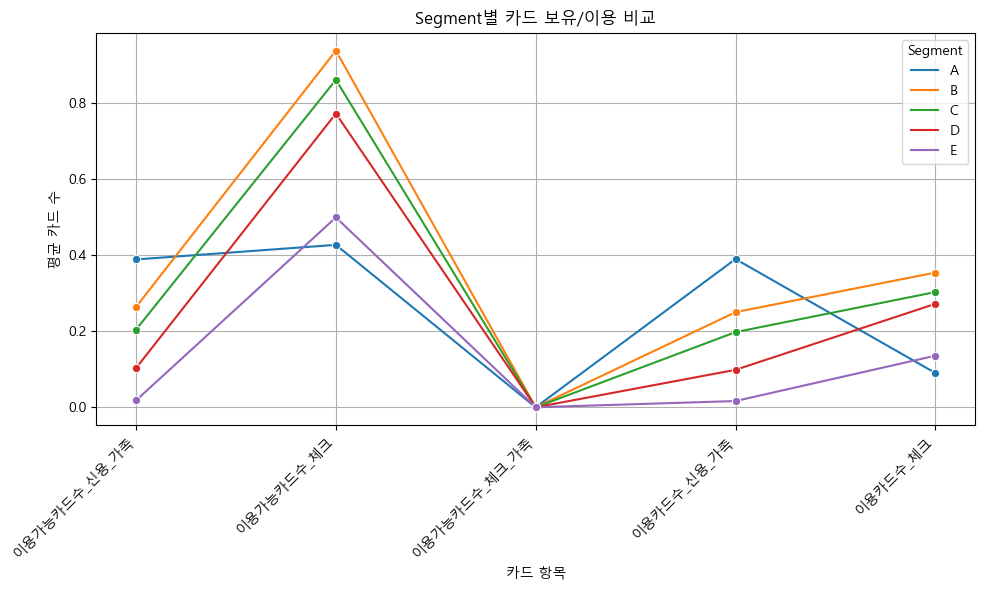

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/HR/Desktop/workspace/파이널프로젝트/회원정보_low_corr_segment_data.csv")

# 2. 사용할 컬럼
cols = [
    '이용가능카드수_신용_가족',
    '이용가능카드수_체크',
    '이용가능카드수_체크_가족',
    '이용카드수_신용_가족',
    '이용카드수_체크'
]

# 3. Segment별 평균값 계산
segment_avg = df.groupby('Segment')[cols].mean().reset_index()

# 4. long형 변환
plot_df = segment_avg.melt(id_vars='Segment', var_name='항목', value_name='평균값')

# 5. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

segment_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
plot_df['Segment'] = plot_df['Segment'].map(segment_map)

# 6. 라인플롯 시각화
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='항목', y='평균값', hue='Segment', marker='o')

plt.title("Segment별 카드 보유/이용 비교")
plt.xlabel("카드 항목")
plt.ylabel("평균 카드 수")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()




C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length

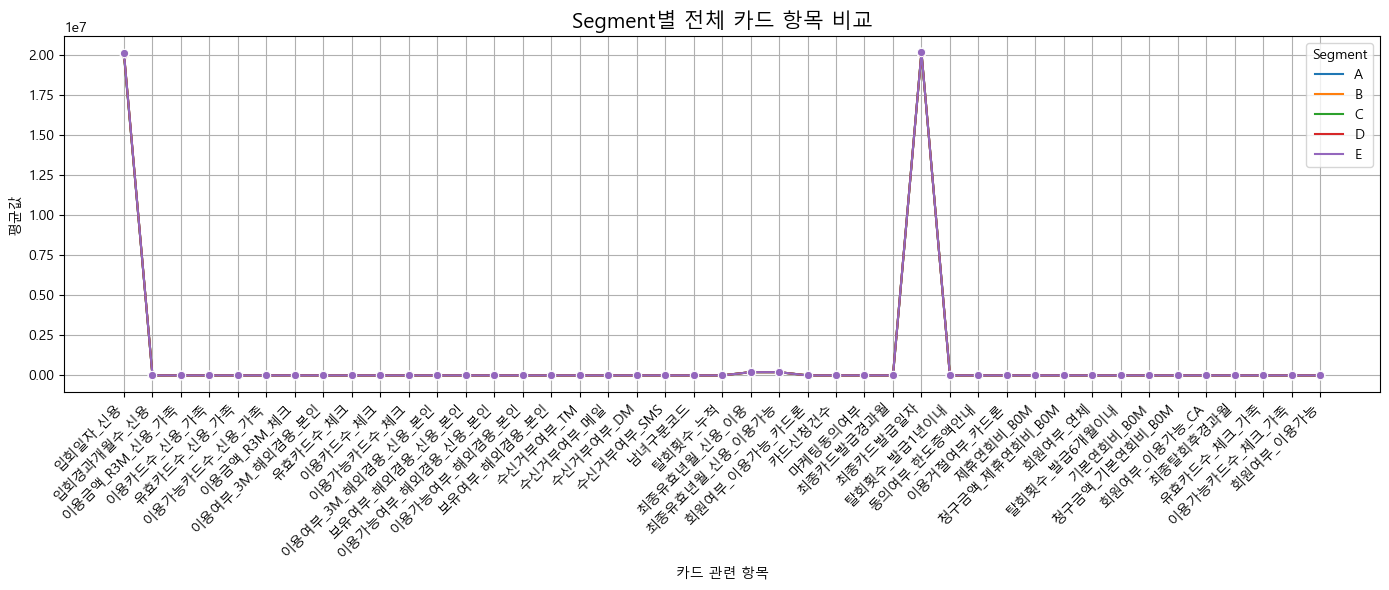

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/HR/Desktop/workspace/파이널프로젝트/회원정보_low_corr_segment_data.csv")

# 2. Segment가 숫자형인 경우 문자로 변환
segment_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
if df['Segment'].dtype != 'object':
    df['Segment'] = df['Segment'].map(segment_map)

# 3. 수치형 컬럼 자동 추출 (Segment 제외)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Segment']

# 4. Segment별 평균값 계산
segment_avg = df.groupby('Segment')[numeric_cols].mean().reset_index()

# 5. long형 변환
plot_df = segment_avg.melt(id_vars='Segment', var_name='항목', value_name='평균값')

# 6. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 7. 라인플롯 시각화
plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x='항목', y='평균값', hue='Segment', marker='o')

plt.title("Segment별 전체 카드 항목 비교", fontsize=15)
plt.xlabel("카드 관련 항목")
plt.ylabel("평균값")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()


C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length

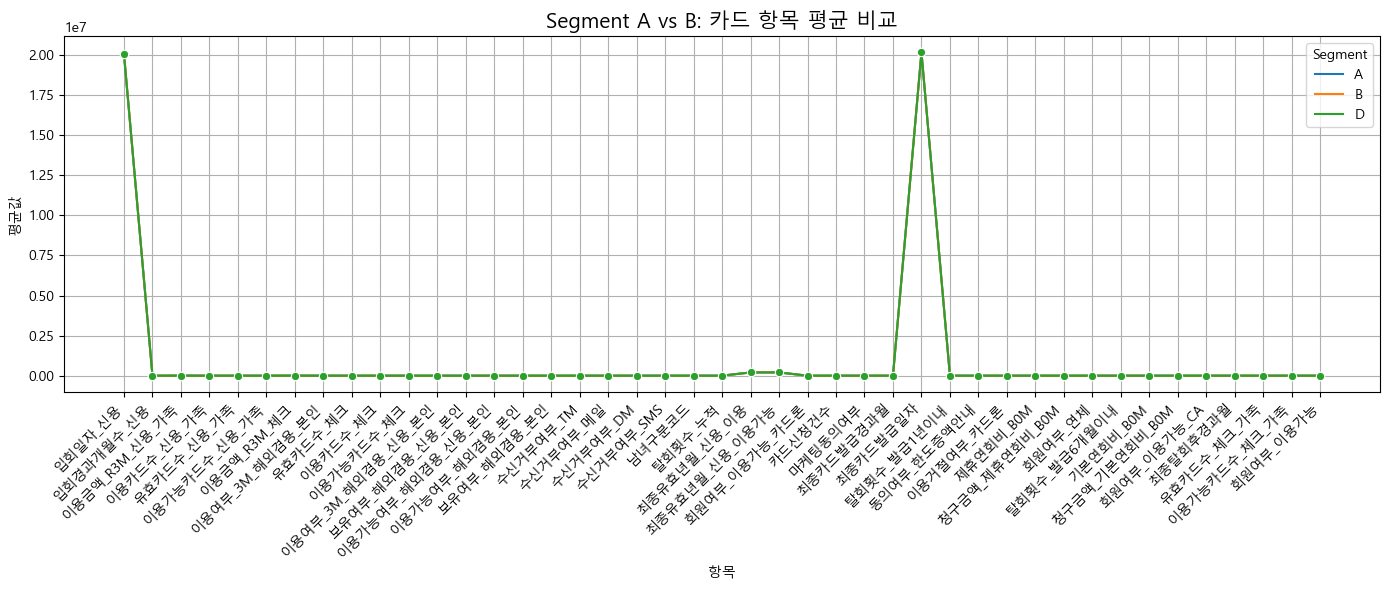

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/HR/Desktop/workspace/파이널프로젝트/회원정보_low_corr_segment_data.csv")

# 2. Segment 문자형 매핑 (숫자인 경우)
segment_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
if df['Segment'].dtype != 'object':
    df['Segment'] = df['Segment'].map(segment_map)

# 3. A, B만 필터링
df_ab = df[df['Segment'].isin(['A', 'B','D'])]

# 4. 수치형 컬럼 추출 (Segment 제외)
numeric_cols = df_ab.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Segment']

# 5. Segment별 평균값 계산
segment_avg = df_ab.groupby('Segment')[numeric_cols].mean().reset_index()

# 6. long형 변환
plot_df = segment_avg.melt(id_vars='Segment', var_name='항목', value_name='평균값')

# 7. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 8. 라인플롯 시각화
plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x='항목', y='평균값', hue='Segment', marker='o')

plt.title("Segment A vs B: 카드 항목 평균 비교", fontsize=15)
plt.xlabel("항목")
plt.ylabel("평균값")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()


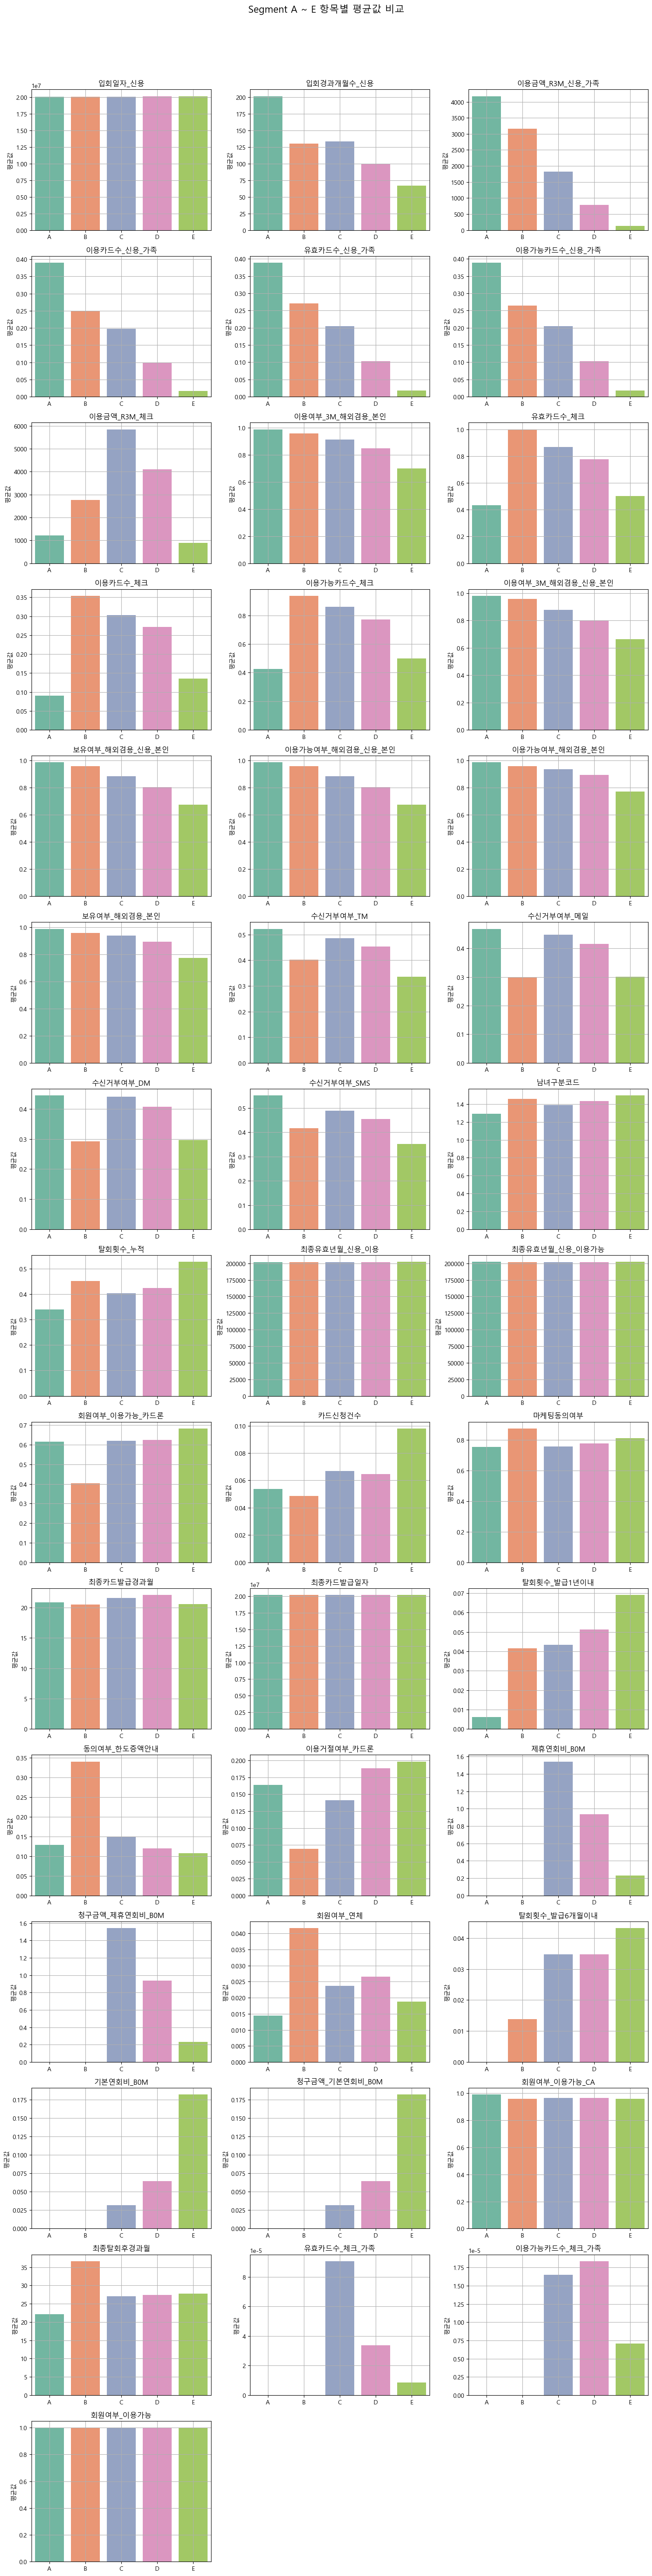

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/HR/Desktop/workspace/파이널프로젝트/회원정보_low_corr_segment_data.csv")

# 2. Segment 문자형 매핑 (숫자인 경우)
segment_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
if df['Segment'].dtype != 'object':
    df['Segment'] = df['Segment'].map(segment_map)

# ✅ 3. 필터링 제거 → 전체 Segment 사용
df_all = df.copy()

# 4. 수치형 컬럼 추출 (Segment 제외)
numeric_cols = df_all.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Segment']

# 5. Segment별 평균값 계산
segment_avg = df_all.groupby('Segment')[numeric_cols].mean().reset_index()

# 6. long형 변환
plot_df = segment_avg.melt(id_vars='Segment', var_name='항목', value_name='평균값')

# 7. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 8. 서브플롯 시각화
num_vars = plot_df['항목'].nunique()
cols = 3
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, 항목 in enumerate(plot_df['항목'].unique()):
    sub_df = plot_df[plot_df['항목'] == 항목]
    sns.barplot(data=sub_df, x='Segment', y='평균값', ax=axes[i], palette='Set2')
    axes[i].set_title(항목)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("평균값")
    axes[i].grid(True)

# 남은 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Segment A ~ E 항목별 평균값 비교", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


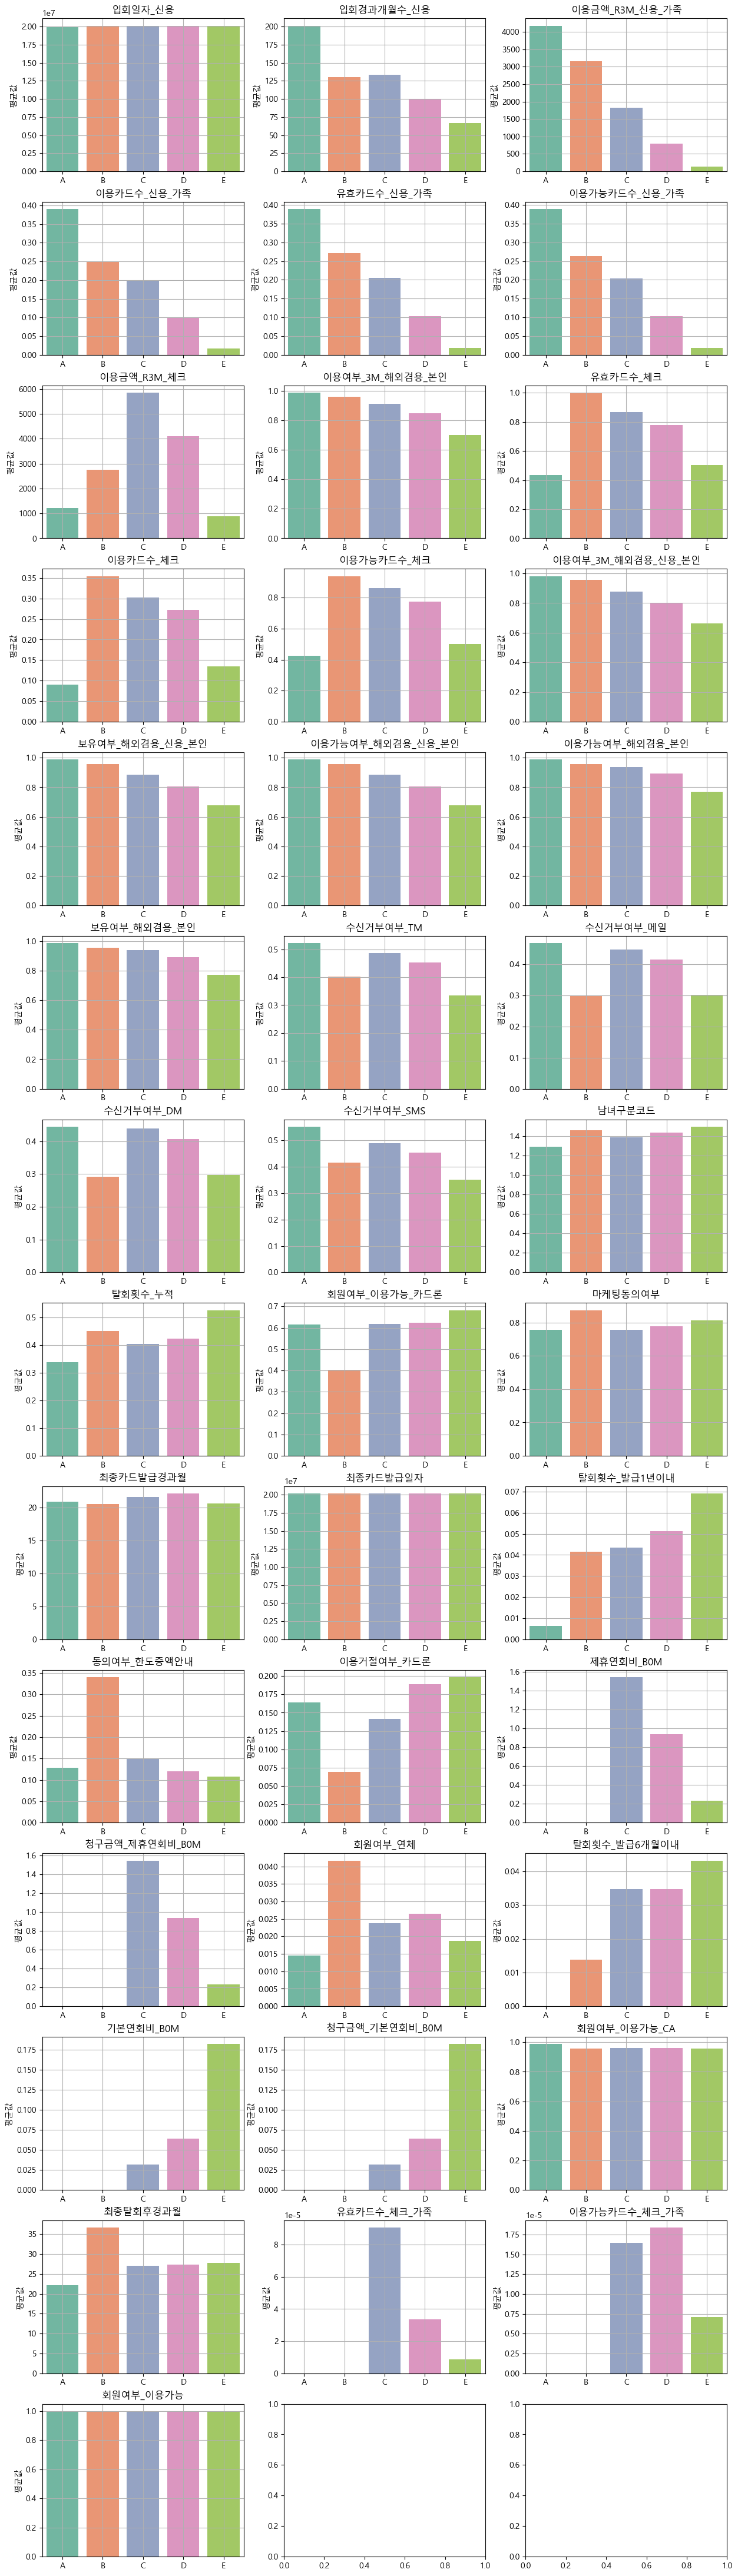

In [15]:
# 1. Segment별 평균값 계산
segment_avg = df.groupby('Segment')[numeric_cols].mean().reset_index()

# 2. long형 변환
plot_df = segment_avg.melt(id_vars='Segment', var_name='항목', value_name='평균값')

# 3. A, B, D 평균이 전체 평균보다 높은 항목만 선택
pivot_df = plot_df.pivot(index='항목', columns='Segment', values='평균값')
pivot_df['전체평균'] = pivot_df.mean(axis=1)

# A, B, D 중 하나라도 전체 평균보다 높은 항목
mask = (
    (pivot_df['A'] > pivot_df['전체평균']) |
    (pivot_df['B'] > pivot_df['전체평균']) |
    (pivot_df['D'] > pivot_df['전체평균'])
)

selected_items = pivot_df[mask].index.tolist()

# 4. 필터링된 항목만 plot_df에서 선택
filtered_plot_df = plot_df[plot_df['항목'].isin(selected_items)]

# 5. 서브플롯 시각화
num_vars = filtered_plot_df['항목'].nunique()
cols = 3
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, 항목 in enumerate(filtered_plot_df['항목'].unique()):
    sub_df = filtered_plot_df[filtered_plot_df['항목'] == 항목]
    sns.barplot(data=sub_df, x='Segment', y='평균값', ax=axes[i], palette='Set2')
    axes[i].set_title(항목)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("평균값")
    axes[i].grid(True)

# 남은 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig


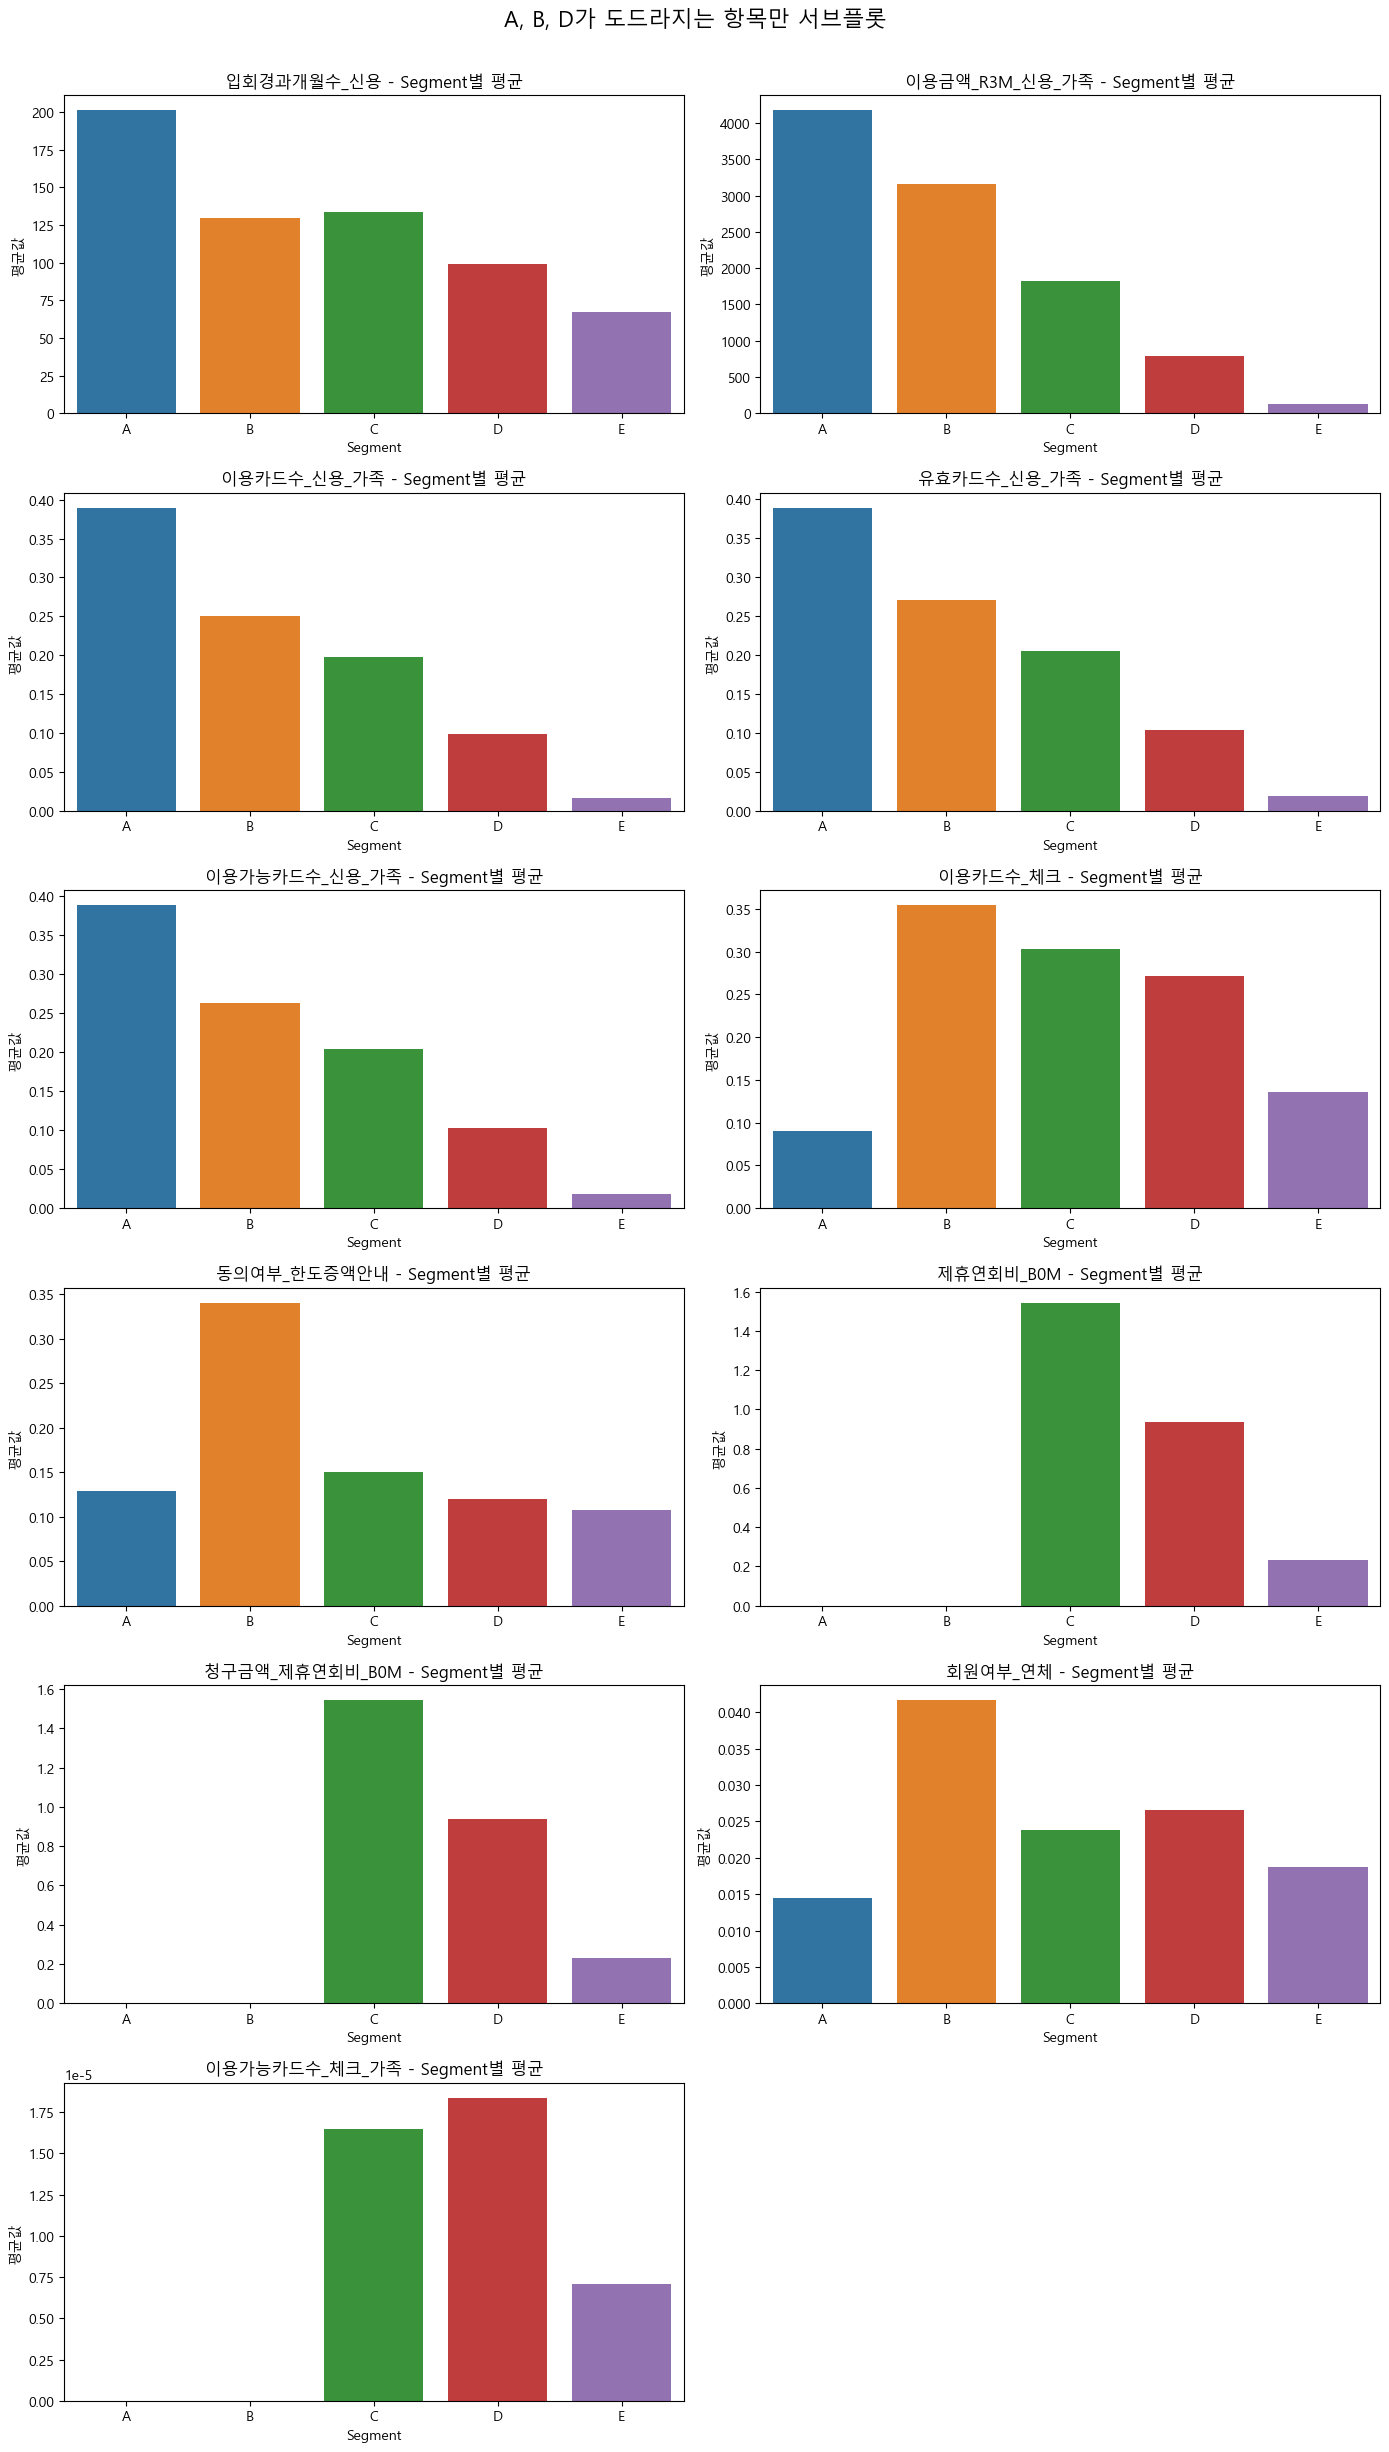

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import math  # 

# 1. Segment별 평균값
segment_avg = df.groupby('Segment')[numeric_cols].mean(numeric_only=True).reset_index()
plot_df = segment_avg.melt(id_vars='Segment', var_name='항목', value_name='평균값')

# 2. 전체 평균 계산
overall_mean = plot_df.groupby('항목')['평균값'].mean().reset_index().rename(columns={'평균값': '전체평균'})

# 3. A, B, D만 필터링
ab_d = plot_df[plot_df['Segment'].isin(['A', 'B', 'D'])]

# 4. 병합 후 비율 계산
merged = pd.merge(ab_d, overall_mean, on='항목')
merged['비율'] = merged['평균값'] / merged['전체평균']

# 5. 1.5배 이상인 항목 추출
highlight_cols = merged[merged['비율'] > 1.5]['항목'].unique()

# 6. 필터링된 항목만 시각화용으로 추출
filtered_plot_df = plot_df[plot_df['항목'].isin(highlight_cols)]

# 7. 서브플롯 시각화
n_cols = 2
n_rows = math.ceil(len(highlight_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(highlight_cols):
    ax = axes[i]
    temp = filtered_plot_df[filtered_plot_df['항목'] == col]  # ✅ 여기 수정
    sns.barplot(data=temp, x='Segment', y='평균값', ax=ax)
    ax.set_title(f"{col} - Segment별 평균", fontsize=12)
    ax.set_xlabel("Segment")
    ax.set_ylabel("평균값")

# 남은 빈 축 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("A, B, D가 도드라지는 항목만 서브플롯", fontsize=16, y=1.02)
plt.show()


C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1

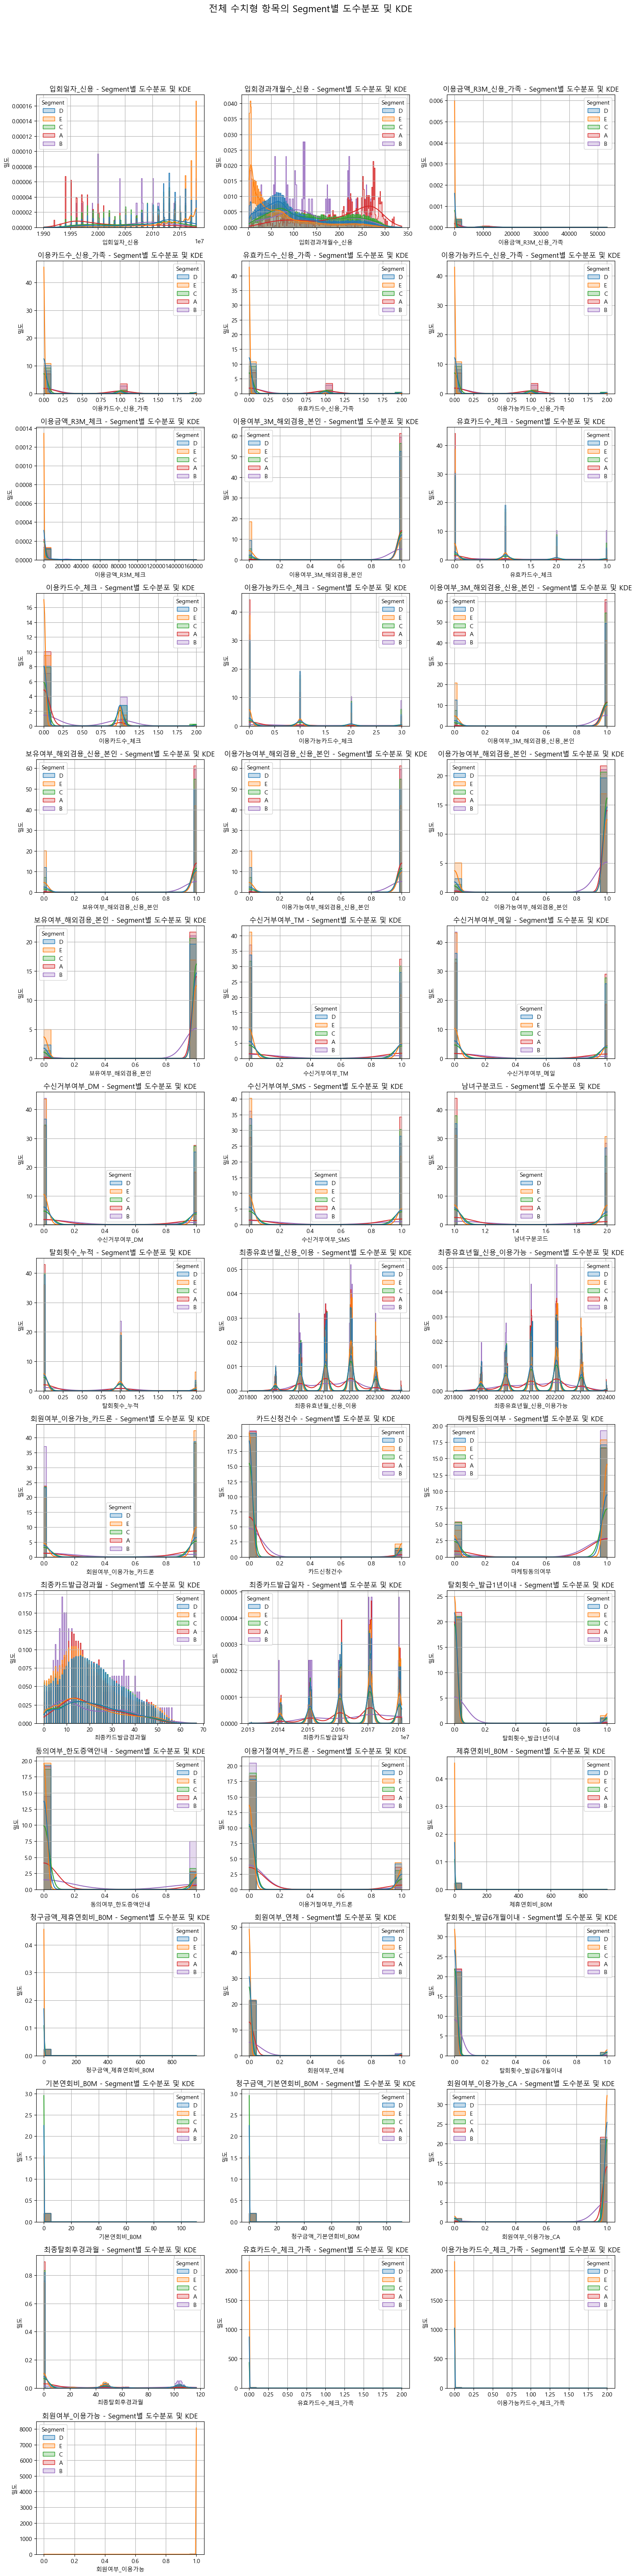

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. 수치형 컬럼 전체 추출 (Segment 제외)
target_cols = df.select_dtypes(include='number').columns.tolist()
target_cols = [col for col in target_cols if col != 'Segment']

# 2. 전체 Segment 포함한 원본 데이터 사용
plot_df = df.copy()

# 3. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 서브플롯 설정
cols = 3
rows = math.ceil(len(target_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

# 5. 항목별 히스토그램 + KDE 시각화
for i, col in enumerate(target_cols):
    ax = axes[i]
    sns.histplot(data=plot_df, x=col, hue='Segment', element='step',
                 stat='density', common_norm=False, kde=True, ax=ax)
    ax.set_title(f"{col} - Segment별 도수분포 및 KDE", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("밀도")
    ax.grid(True)

# 6. 남은 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 7. 전체 제목 및 레이아웃
plt.tight_layout()
plt.suptitle("전체 수치형 항목의 Segment별 도수분포 및 KDE", fontsize=16, y=1.03)
plt.show()



In [23]:
# 실제 컬럼명 리스트 확인
print(df.columns.tolist())

# 예: selected_cols 리스트 확인
print(selected_cols)


['입회일자_신용', '입회경과개월수_신용', '이용금액_R3M_신용_가족', '이용카드수_신용_가족', '유효카드수_신용_가족', '이용가능카드수_신용_가족', '이용금액_R3M_체크', '이용여부_3M_해외겸용_본인', '유효카드수_체크', '이용카드수_체크', '이용가능카드수_체크', '이용여부_3M_해외겸용_신용_본인', '보유여부_해외겸용_신용_본인', '이용가능여부_해외겸용_신용_본인', '이용가능여부_해외겸용_본인', '보유여부_해외겸용_본인', '수신거부여부_TM', '수신거부여부_메일', '수신거부여부_DM', '수신거부여부_SMS', '남녀구분코드', '탈회횟수_누적', '최종유효년월_신용_이용', '최종유효년월_신용_이용가능', '회원여부_이용가능_카드론', '카드신청건수', '마케팅동의여부', '최종카드발급경과월', '최종카드발급일자', '탈회횟수_발급1년이내', '동의여부_한도증액안내', '이용거절여부_카드론', '제휴연회비_B0M', '청구금액_제휴연회비_B0M', '회원여부_연체', '탈회횟수_발급6개월이내', '기본연회비_B0M', '청구금액_기본연회비_B0M', '회원여부_이용가능_CA', '최종탈회후경과월', '유효카드수_체크_가족', '이용가능카드수_체크_가족', '회원여부_이용가능', 'Segment']
['청구금액_제휴연회비_B0M', '유효카드수_체크_가족', '제휴연회비_B0M', '이용금액_R3M_체크']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 사용할 변수 목록 (컬럼명 정확히 확인됨)
target_cols = [
    '청구금액_제휴연회비_B0M',
    '유효카드수_체크_가족',
    '제휴연회비_B0M',
    '이용금액_R3M_체크'
]

# 각 변수별 Swarmplot 시각화
for col in target_cols:
    plt.figure(figsize=(8, 6))
    sns.swarmplot(data=df, x='Segment', y=col)
    plt.title(f'Segment별 {col} 분포 (Swarmplot)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
